# **Estadística computacional - Grupo B**

**Integrantes:**

- Cristóbal Flores Campusano 

  Rol: 202473111-4
- Joaquín Solís Quintanilla 

  Rol: 202404077-4

- Josefa Vidal Toro

  Rol: 202373047-5
  
- Zi Xuan He

  Rol: 202473090-8


# **Entrega #2: Simulación e Inferencia**


# Resumen entrega anterior:

Dataset seleccionado: Ventas de videojuegos.

En la entrega 1 se realizó un análisis exporatorio de datos, también conocido como EDA, sobre el dataset seleccionado. Este conjunto de datos contiene información sobre videojuegos en distintas plataformas, géneros, años de lanzamiento y ventas regionales, incluyendo Norteamérica, Europa, Japón y ventas globales.

Antes de realizar el análisis, se aplicó un proceso de limpieza de datos, en donde se eliminó la columna "Publisher", ya que no era relevate para el análisis principal. Dentro de los principales resultados obtenidos, se pudo observar que:

1. El género Action fue el mas frecuente, seguido por Sports.
2. Las ventas regionales presentan una distribución asimétrica, donde la mayoría de los videojuegos tienen ventas bajas, pero existen títulos con ventas muy altas.
3. Se identificaron diferencias entre las ventas según su género.
4. Japón presentó un comportamiento particular en comparación con las otras regiones.

A partir de estos resultados, se planteó responder la siguiente pregunta de investigación: 

¿La relación entre el género y las ventas de videojuegos cambia según la región?


Objetivos:


Media de ventas por género y región:


,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,0.2647,0.1583,0.0482
Adventure,0.0823,0.0499,0.0405
Fighting,0.2637,0.1195,0.1030
Misc,0.2359,0.1242,0.0620
Platform,0.5046,0.2276,0.1476
Puzzle,0.2127,0.0873,0.0985
Racing,0.2878,0.1909,0.0454
Role-Playing,0.2199,0.1264,0.2368
Shooter,0.4447,0.2391,0.0292


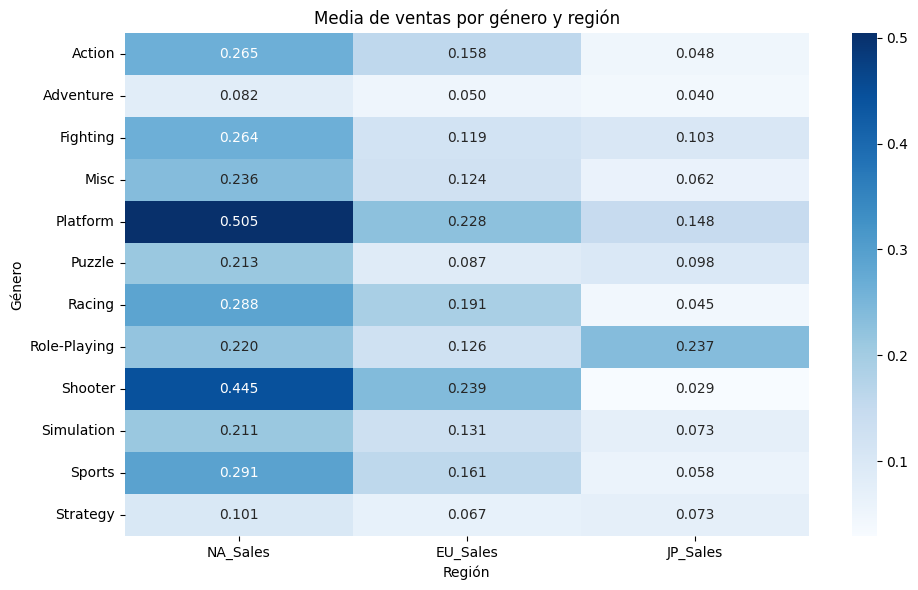

Proporción de ventas de cada género dentro de cada región:


,NA_Sales,EU_Sales,JP_Sales
Genre,,,
Action,19.98,21.57,12.39
Adventure,2.41,2.63,4.03
Fighting,5.09,4.16,6.77
Misc,9.34,8.87,8.35
Platform,10.18,8.28,10.13
Puzzle,2.82,2.09,4.44
Racing,8.18,9.79,4.39
Role-Playing,7.45,7.73,27.29
Shooter,13.26,12.87,2.97


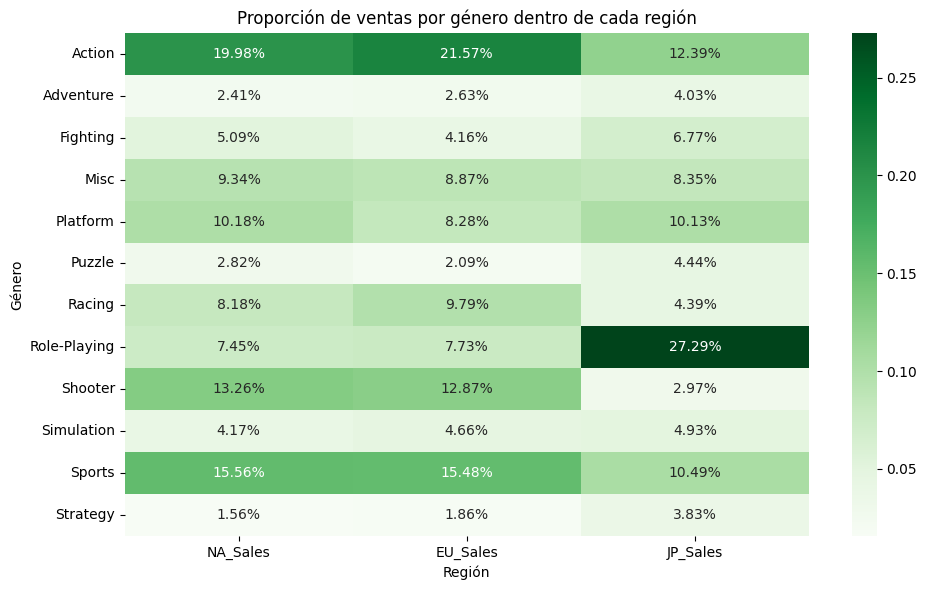

Géneros con mayor diferencia de media entre regiones:


,Region_media_mayor,Media_mayor,Region_media_menor,Media_menor,Diferencia_max_min
Genre,,,,,
Shooter,NA_Sales,0.4447,JP_Sales,0.0292,0.4155
Platform,NA_Sales,0.5046,JP_Sales,0.1476,0.3570
Racing,NA_Sales,0.2878,JP_Sales,0.0454,0.2424
Sports,NA_Sales,0.2913,JP_Sales,0.0577,0.2336
Action,NA_Sales,0.2647,JP_Sales,0.0482,0.2165
Misc,NA_Sales,0.2359,JP_Sales,0.0620,0.1739
Fighting,NA_Sales,0.2637,JP_Sales,0.1030,0.1607
Simulation,NA_Sales,0.2114,JP_Sales,0.0735,0.1380
Puzzle,NA_Sales,0.2127,EU_Sales,0.0873,0.1254


Géneros con mayor diferencia de proporción entre regiones:


,Region_proporcion_mayor,Proporcion_mayor,Region_proporcion_menor,Proporcion_menor,Diferencia_max_min
Genre,,,,,
Role-Playing,JP_Sales,0.2729,NA_Sales,0.0745,0.1984
Shooter,NA_Sales,0.1326,JP_Sales,0.0297,0.1030
Action,EU_Sales,0.2157,JP_Sales,0.1239,0.0918
Racing,EU_Sales,0.0979,JP_Sales,0.0439,0.0540
Sports,NA_Sales,0.1556,JP_Sales,0.1049,0.0507
Fighting,JP_Sales,0.0677,EU_Sales,0.0416,0.0260
Puzzle,JP_Sales,0.0444,EU_Sales,0.0209,0.0235
Strategy,JP_Sales,0.0383,NA_Sales,0.0156,0.0227
Platform,NA_Sales,0.1018,EU_Sales,0.0828,0.0189


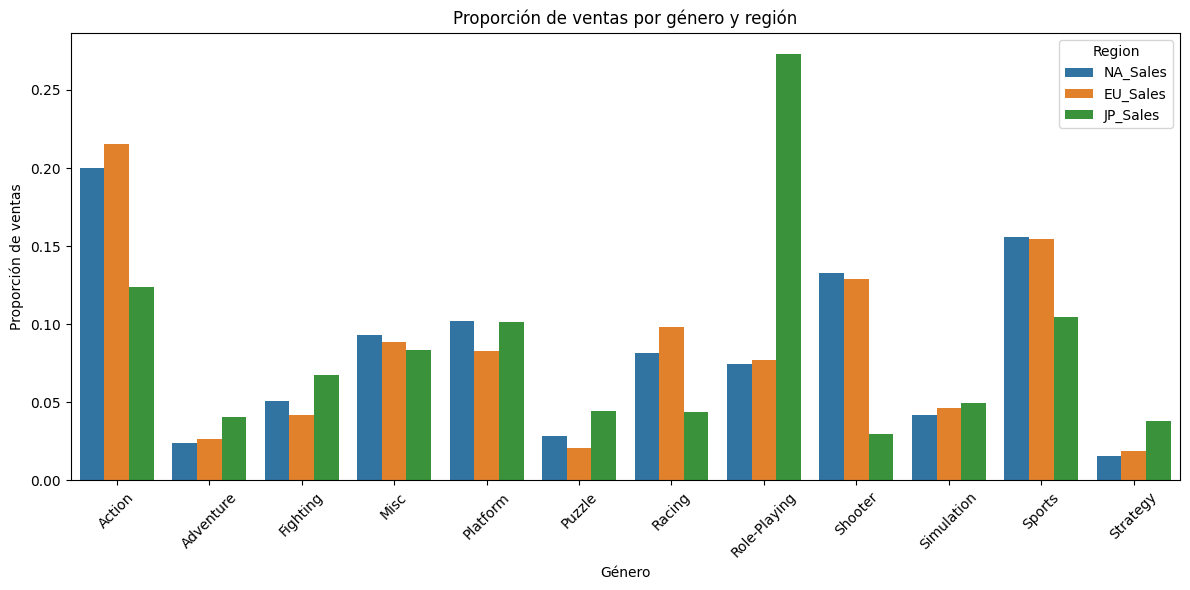

Interpretación de la estimación puntual:

A partir de la media de ventas por género y región, se observa que algunos géneros presentan
diferencias en su desempeño promedio dependiendo de la región analizada.

Los géneros con mayor diferencia en medias entre regiones son:
- Shooter: mayor media en NA_Sales (0.4447) y menor media en JP_Sales (0.0292). Diferencia: 0.4155.
- Platform: mayor media en NA_Sales (0.5046) y menor media en JP_Sales (0.1476). Diferencia: 0.3570.
- Racing: mayor media en NA_Sales (0.2878) y menor media en JP_Sales (0.0454). Diferencia: 0.2424.
- Sports: mayor media en NA_Sales (0.2913) y menor media en JP_Sales (0.0577). Diferencia: 0.2336.
- Action: mayor media en NA_Sales (0.2647) y menor media en JP_Sales (0.0482). Diferencia: 0.2165.

A partir de las proporciones de ventas, se observa qué géneros tienen mayor peso relativo
dentro de cada mercado regional.

Los géneros con mayor diferencia en proporción entre regiones son:
- Role-Playing: mayor proporción en JP

In [2]:
# ============================================================
# ESTIMACIÓN PUNTUAL
# Pregunta: ¿La relación entre el género y las ventas de videojuegos cambia según la región?
# Regiones consideradas: Norteamérica, Europa y Japón
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data= pd.read_csv("vgsales.csv")

# Regiones principales del análisis
regiones = ["NA_Sales", "EU_Sales", "JP_Sales"]

# Verificación de columnas necesarias
columnas_necesarias = ["Genre"] + regiones
faltantes = [col for col in columnas_necesarias if col not in data.columns]

if faltantes:
    raise ValueError(f"Faltan columnas en el dataset: {faltantes}")

# Copia del dataset para esta sección
data_est = data[columnas_necesarias].dropna().copy()

# Asegurar que las ventas sean numéricas
for region in regiones:
    data_est[region] = pd.to_numeric(data_est[region], errors="coerce")

data_est = data_est.dropna()

# ============================================================
# Estimador 1: media muestral de ventas por género y región
# ============================================================

medias_genero_region = data_est.groupby("Genre")[regiones].mean()

print("Media de ventas por género y región:")
display(medias_genero_region.round(4))

# Gráfico tipo heatmap para visualizar las medias

plt.figure(figsize=(10, 6))
sns.heatmap(
    medias_genero_region,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)

plt.title("Media de ventas por género y región")
plt.xlabel("Región")
plt.ylabel("Género")
plt.tight_layout()
plt.show()


# ============================================================
# Estimador 2: proporción de ventas de cada género por región
# ============================================================

ventas_genero_region = data_est.groupby("Genre")[regiones].sum()
ventas_totales_region = data_est[regiones].sum()

proporciones_genero_region = ventas_genero_region.div(ventas_totales_region, axis=1)

print("Proporción de ventas de cada género dentro de cada región:")
display((proporciones_genero_region * 100).round(2))


# Gráfico tipo heatmap para visualizar proporciones

plt.figure(figsize=(10, 6))
sns.heatmap(
    proporciones_genero_region,
    annot=True,
    fmt=".2%",
    cmap="Greens"
)

plt.title("Proporción de ventas por género dentro de cada región")
plt.xlabel("Región")
plt.ylabel("Género")
plt.tight_layout()
plt.show()


# ============================================================
# Diferencias regionales usando medias
# ============================================================

resumen_medias = pd.DataFrame({
    "Region_media_mayor": medias_genero_region.idxmax(axis=1),
    "Media_mayor": medias_genero_region.max(axis=1),
    "Region_media_menor": medias_genero_region.idxmin(axis=1),
    "Media_menor": medias_genero_region.min(axis=1),
    "Diferencia_max_min": medias_genero_region.max(axis=1) - medias_genero_region.min(axis=1)
})

resumen_medias = resumen_medias.sort_values("Diferencia_max_min", ascending=False)

print("Géneros con mayor diferencia de media entre regiones:")
display(resumen_medias.round(4))


# ============================================================
# Diferencias regionales usando proporciones
# ============================================================

resumen_proporciones = pd.DataFrame({
    "Region_proporcion_mayor": proporciones_genero_region.idxmax(axis=1),
    "Proporcion_mayor": proporciones_genero_region.max(axis=1),
    "Region_proporcion_menor": proporciones_genero_region.idxmin(axis=1),
    "Proporcion_menor": proporciones_genero_region.min(axis=1),
    "Diferencia_max_min": proporciones_genero_region.max(axis=1) - proporciones_genero_region.min(axis=1)
})

resumen_proporciones = resumen_proporciones.sort_values("Diferencia_max_min", ascending=False)

print("Géneros con mayor diferencia de proporción entre regiones:")
display((resumen_proporciones * 100).round(2) if False else resumen_proporciones.round(4))


# Convertir tabla de proporciones a formato largo para graficar

proporciones_largo = proporciones_genero_region.reset_index().melt(
    id_vars="Genre",
    value_vars=regiones,
    var_name="Region",
    value_name="Proporcion"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=proporciones_largo,
    x="Genre",
    y="Proporcion",
    hue="Region"
)

plt.title("Proporción de ventas por género y región")
plt.xlabel("Género")
plt.ylabel("Proporción de ventas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# Interpretación básica automática
# ============================================================

print("Interpretación de la estimación puntual:\n")

print("A partir de la media de ventas por género y región, se observa que algunos géneros presentan")
print("diferencias en su desempeño promedio dependiendo de la región analizada.")

print("\nLos géneros con mayor diferencia en medias entre regiones son:")
for genero, fila in resumen_medias.head(5).iterrows():
    print(
        f"- {genero}: mayor media en {fila['Region_media_mayor']} "
        f"({fila['Media_mayor']:.4f}) y menor media en {fila['Region_media_menor']} "
        f"({fila['Media_menor']:.4f}). Diferencia: {fila['Diferencia_max_min']:.4f}."
    )

print("\nA partir de las proporciones de ventas, se observa qué géneros tienen mayor peso relativo")
print("dentro de cada mercado regional.")

print("\nLos géneros con mayor diferencia en proporción entre regiones son:")
for genero, fila in resumen_proporciones.head(5).iterrows():
    print(
        f"- {genero}: mayor proporción en {fila['Region_proporcion_mayor']} "
        f"({fila['Proporcion_mayor']:.2%}) y menor proporción en {fila['Region_proporcion_menor']} "
        f"({fila['Proporcion_menor']:.2%}). Diferencia: {fila['Diferencia_max_min']:.2%}."
    )

# Estimación puntual:

Parámetro 1: Diferencia de medias de ventas de un mismo género en distintas regiones.

$$
\hat{\theta}_1 = \bar{x}_{g,r_{1}} - \bar{x}_{g,r_{2}}
$$

Donde $\bar{x}_{g,r_{1}}$ representa la media muestral de ventas de un género $g$ en la región $r_{1}$.


Se consideró que este parámetro era pertinente para el problema de investigación, ya que, permite medir si el desepeño promedio de un género cambia dependiendo de la región. 

Esto se conecta directamente con la pregunta de investigación, debido a que permite evaluar si un mismo género tiene distintos niveles de ventas según el mercado analizado. 

Parámetro 2: Diferencia entre las proporciones de participación de un género específico en las ventas totales de distintas regiones.

$$
\hat{\theta}_2 = \hat{p}_{g,r_{1}} - \hat{p}_{g,r_{2}}
$$

Donde $\hat{p}_{g,r_{1}}$ corresponde a la proporción de ventas de un género en una región respecto a las ventas totales del mercado regional ${V_{r}}$, calculándose como:

$$
p_{g,r} = \frac{V_{g,r}}{V_{r}}
$$

Donde ${V_{g,r}}$ representa las ventas del género $g$ en la región $r$.

Se consideró pertintente porque permite analizar la importancia que tiene el género dentro de cada mercado regional.

Ambos parámetros permiten estudiar la pregunta de investigación, comparando el rendimiento de un género entre regiones y la participación de este en un mercado regional.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data= pd.read_csv("vgsales.csv")

genero = "Role-Playing"
region_1 = "JP_Sales"
region_2 = "NA_Sales"

datos_genero = data[data["Genre"] == genero]

#Estimador puntual 1:

media_ventas_region_1 = datos_genero[region_1].mean()
media_ventas_region_2 = datos_genero[region_2].mean()

estimador_puntual_1 = media_ventas_region_1 - media_ventas_region_2

#Estimador puntual 2:

ventas_totales_genero_region_1 = datos_genero[region_1].sum()
ventas_totales_genero_region_2 = datos_genero[region_2].sum()

ventas_totales_region_1 = data[region_1].sum()
ventas_totales_region_2 = data[region_2].sum()

proporcion_region_1 = ventas_totales_genero_region_1 / ventas_totales_region_1
proporcion_region_2 = ventas_totales_genero_region_2 / ventas_totales_region_2

estimador_puntual_2 = proporcion_region_1 - proporcion_region_2

print("Género seleccionado:", genero)
print("Regiones comparadas:", "Japón", "v/s", "Norteamérica")

print("\nMedia de ventas en Japón para el género seleccionado:", media_ventas_region_1)
print("Media de ventas en Norteamérica para el género seleccionado:", media_ventas_region_2)
print("Estimador puntual 1 (Diferencia de medias):", estimador_puntual_1)

print("\nVentas totales del género seleccionado en Japón:", ventas_totales_genero_region_1)
print("Ventas totales del género seleccionado en Norteamérica:", ventas_totales_genero_region_2)
print("Ventas totales en Japón:", ventas_totales_region_1)  
print("Ventas totales en Norteamérica:", ventas_totales_region_2)
print("Estimador puntual 2 (Diferencia de proporciones):", estimador_puntual_2)



Género seleccionado: Role-Playing
Regiones comparadas: Japón v/s Norteamérica

Media de ventas en Japón para el género seleccionado: 0.23676747311827956
Media de ventas en Norteamérica para el género seleccionado: 0.21994623655913978
Estimador puntual 1 (Diferencia de medias): 0.01682123655913978

Ventas totales del género seleccionado en Japón: 352.31
Ventas totales del género seleccionado en Norteamérica: 327.28
Ventas totales en Japón: 1291.02
Ventas totales en Norteamérica: 4392.950000000001
Estimador puntual 2 (Diferencia de proporciones): 0.19839156206207925


# Métodos de remuestreo: Bootstrap

## Origen, motivación y relevancia del bootstrap:

El bootstrap es una técnica estadística de remuestreo que permite estudiar la variabilidad de un estimador a partir de la muestra observada. Su idea principal consiste en generar muchas muestras artificiales, denominadas muestras bootstrap, tomando datos al azar desde la muestra original, permitiendo que un mismo dato pueda repetirse más de una vez en una nueva muestra. Posteriormente, en cada una de estas muestras se calcula el valor que se quiere analizar, como una media, una proporción o una diferencia de medias, para obtener una distribución aproximada del estimador.

Este método fue propuesto por Bradley Efron en 1979, en su trabajo "Bootstrap Methods: Another Look at the Jackknife". Su origen se relaciona con la necesidad de mejorar y generalizar los métodos anteriores de remuestreo, como el jackknife, especialmente en casos donde era difícil obtener fórmulas teóricas para calcular el error estándar, el sesgo o la distribución de un estimador.

La motivación principal del bootstrap es que, en muchos problemas reales, solo cuentan con una muestra y no con toda la población de los datos. Es por esto que el método utiliza la muestra disponible como una aproximación de la población, permitiendo analizar cómo podría variar un estimador si se repitiera el proceso de muestreo varias veces.

La relevancia del bootstrap en la estadística moderna se debe a que es un método flexible, intuitivo y muy útil para el análisis de datos. Además permite estudiar la incertidumbre sin depender completamente de suspuestos teóricos, como la normalidad de los datos. En este análisis, nos será útil para evaluar la estabilidad de los parámetros escogidos.




In [2]:
# elegimos el genero
juegos_accion = data[data['Genre'] == 'Action']

# calculamos el promedio de la media
media_jp_real = juegos_accion['JP_Sales'].mean()
media_na_real = juegos_accion['NA_Sales'].mean()

# obtenemso la diferencia de lso promedios
dif_medias_observada = media_jp_real - media_na_real

print(f"Venta promedio en Japón: {media_jp_real:.4f} millones")
print(f"Venta promedio en Norteamérica: {media_na_real:.4f} millones")
print(f"Diferencia de Medias Real: {dif_medias_observada:.4f}")

Venta promedio en Japón: 0.0482 millones
Venta promedio en Norteamérica: 0.2647 millones
Diferencia de Medias Real: -0.2165


Intervalo de Confianza para Medias: [-0.2362, -0.1984]


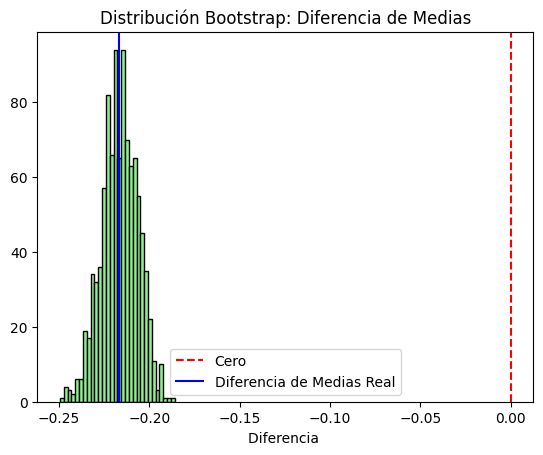

In [3]:
resultados_bs_medias = []

for i in range(1000):
    # Lo mas imporatante el boot
    muestra_bs = data.sample(frac=1, replace=True)

    # filtramos por género
    filtro = muestra_bs[muestra_bs['Genre'] == 'Action']

    # calculamos la media
    m_jp = filtro['JP_Sales'].mean()
    m_na = filtro['NA_Sales'].mean()

    # guardamos la resta de las medias
    resultados_bs_medias.append(m_jp - m_na)

# calculamos el Intervalo de Confianza
inf_m = np.percentile(resultados_bs_medias, 2.5)
sup_m = np.percentile(resultados_bs_medias, 97.5)

print(f"Intervalo de Confianza para Medias: [{inf_m:.4f}, {sup_m:.4f}]")
# graficamos
plt.hist(resultados_bs_medias, bins=30, color='lightgreen', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Cero')
plt.axvline(dif_medias_observada, color='blue', label='Diferencia de Medias Real')

plt.title('Distribución Bootstrap: Diferencia de Medias')
plt.xlabel('Diferencia ')
plt.legend()
plt.show()

In [4]:
# Defini el genero a analizar
genero_interes = 'Action'

# Las ventas globales de las regiones a comparar
total_jp = data['JP_Sales'].sum()
total_na = data['NA_Sales'].sum()

# Las entas del genero específico por región
ventas_genero_jp = data[data['Genre'] == genero_interes]['JP_Sales'].sum()
ventas_genero_na = data[data['Genre'] == genero_interes]['NA_Sales'].sum()

# Proporciones
prop_jp_real = ventas_genero_jp / total_jp
prop_na_real = ventas_genero_na / total_na

# La diferencia real
diferencia_observada = prop_jp_real - prop_na_real

print(f"Proporción en Japón: {prop_jp_real:.4f}")
print(f"Proporción en Norteamérica: {prop_na_real:.4f}")
print(f"Diferencia Real: {diferencia_observada:.4f}")

Proporción en Japón: 0.1239
Proporción en Norteamérica: 0.1998
Diferencia Real: -0.0759


In [7]:
# Lista para guardar los resultados
resultados_bootstrap = []
n_repeticiones = 1000

for i in range(n_repeticiones):
    # Esto hace que sea boot
    muestra_bs = data.sample(frac=1, replace=True)

    # calculamos aleatoriamente
    t_jp = muestra_bs['JP_Sales'].sum()
    t_na = muestra_bs['NA_Sales'].sum()

    v_g_jp = muestra_bs[muestra_bs['Genre'] == genero_interes]['JP_Sales'].sum()
    v_g_na = muestra_bs[muestra_bs['Genre'] == genero_interes]['NA_Sales'].sum()

    p_jp = v_g_jp / t_jp
    p_na = v_g_na / t_na

    # guardamos la diferencia en la lista
    resultados_bootstrap.append(p_jp - p_na)


Intervalo de Confianza: [-0.0923, -0.0577]


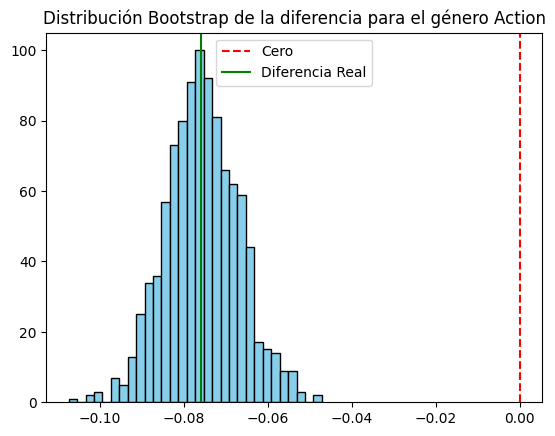

In [6]:
# percentiles del 95% el intervalo de confianza
inferior = np.percentile(resultados_bootstrap, 2.5)
superior = np.percentile(resultados_bootstrap, 97.5)

print(f"Intervalo de Confianza: [{inferior:.4f}, {superior:.4f}]")

# Graficamos
plt.hist(resultados_bootstrap, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Cero')
plt.axvline(diferencia_observada, color='green', label='Diferencia Real')
plt.title(f'Distribución Bootstrap de la diferencia para el género {genero_interes}')
plt.legend()
plt.show()

# Simulación por Monte Carlo

## ¿En qué consiste el método Monte Carlo?

El método Monte Carlo es una técnica estadística implementada en diversas disciplinas para evaluar la incertidumbre y el riesgo en modelos matemáticos mediante la simulación de escenarios basados en variables aleatorias. Esta técnica permite estimar probabilidades, promedios y variabilidad en sistemas complejos, especialmente cuando el fenómeno estudiado no puede analizarse fácilmente de forma exacta.

Para llevar a cabo el análisis de Monte Carlo de manera efectiva, es fundamental seguir los siguientes pasos:

1. **Definir el problema y el modelo**: se debe establecer claramente el fenómeno o sistema que se desea analizar, junto con el modelo matemático que lo representa, identificando las variables involucradas.

2. **Identificar las variables de entrada**: se determina qué parámetros del modelo son inciertos y, para cada uno de ellos, se asigna una distribución de probabilidad adecuada, como normal, uniforme o triangular, según la información disponible o algún supuesto razonable.

3. **Generar valores aleatorios**: a partir de las distribuciones definidas, se crean valores simulados seleccionando aleatoriamente un valor para cada variable de entrada. 

4. **Simulación**: se repite el proceso anterior durante varias iteraciones, por ejemplo 100, 1000 o 5000 veces. Cada iteración representa a un escenario diferente, lo que permite generar una distribución completa de posibles resultados.

5. **Analizar los resultados**: por último, se estudian los resultados obtenidos mediante estadísticas descriptivas, como promedio, varianza y desviación estándar, además de visualizaciones que permitan evaluar la incertidumbre del fenómeno analizado.

El próposito de implementar este método en nuestro análisis es complementar la 
estimación puntual clásica y el método bootstrap. Estos métodos permiten caracterizar los estimadores a partir de la evidencia contenida en la muestra, pero Monte Carlo permite analizar cómo podrían variar nuestras conclusiones bajo distintos escenarios simulados. En este caso, el método se utilizará para evaluar la estabilidad de los estimadores relacionados con las ventas de un mismo género entre dos regiones, considerando posibles eventos aleatorios del mercado.

## Situación de interés:


El cuál para este sección buscamos Evaluar la estabilidad de la diferencia de ventas entre regiones frente a fluctuaciones del mercado. 

Para ellos, se modelan las ventas de cada región como variables aleatorias independientes, es decir que los valores simulados cambian en cada escenario y que el comportamiento de una región no influye directamente en la otra. El cuál utlizamos el siguiente modelo matemático.

$ \triangle Ventas = V_{regionA}- V_{region B}.$


- hay que definir como se generan las ventas de A y B aleatoriamente.

- Simularlo varias veces.

- Hacemos gráficos con ellos.